# 18. stage-1 MC 가격 예측 — MC 변형 A vs B (DeepONet · XGB)

노트북 17 의 두 MC 를 **전체 58,790개 상품**에 대해 새로 산출하고, 각 MC 를 타깃으로 **stage-1 (MC 이론가 앵커)** 을 학습해
MC 가격 예측 성능을 비교한다.

| | A: 배당 없음 · NS · HV120 | B: 이산배당 · 부트스트랩 · EWMA120 |
|---|---|---|
| 커브 (드리프트 · 할인) | NS 3점 정확 적합 (콜 · CD91 · 국고채 10년, 발행월 값) | CD91(직전 완결월) + IRS 1~20년(발행 직전 영업일) 부트스트랩 |
| 변동성 | 각 시장 발행 전 120 거래일 단순 표준편차 × √252 | 같은 120 거래일, EWMA λ = 0.99 (반감기 69 거래일) |
| 상관 | 발행 전 한국 영업일 120일 창, 쌍마다 두 시장이 모두 거래한 날의 Pearson | 같음 |
| 배당 | q = 0 | 이산배당 (발행 전 1년 분배 이력을 만기까지 매년 투영; DAX 는 총수익지수라 0) |
| 엔진 | 노트북 5 인라인 엔진 · 일별 GBM · 40,000 경로 · seed = `mc_seed` (A · B 같은 난수) | 같음 |

## stage-1 설정

stage-1 은 MC 이론가의 대리모형(MC_hat)이다. 입력이 MC 의 입력과 다르면 배울 수 없는 부분이 생기므로,
변형마다 정본 `build_source` 규칙 그대로 입력을 다시 만든다.

| stage-1 입력 | A | B |
|---|---|---|
| branch: 바스켓 vol · corr (VC) | σ(HV120) 오름차순 3 · 상관 오름차순 3 · sig_eff | σ(EWMA120) 오름차순 3 · 상관 오름차순 3 · sig_eff · **배당수익률 q 3개** (σ 와 같은 순서) |
| branch: 곡선 (u0 ~ u9) | NS 제로금리 (0.25 · 0.5 · 1 · 1.5 · 2 · 3 · 4 · 5 · 7 · 10년) | 부트스트랩 제로금리 (같은 노드) |
| trunk: 계약 | 행사가 · 지급률 · 리자드 스케줄 · 배리어 · 쿠폰 · 만기 (51) | 같음 |

- **타깃**: 각 변형의 MC 가격. 학습 · 조기종료 · 평가 모두 MC 만 쓴다.
- **모델**: DeepONet-Curve 앵커(`model/deeponet.py`), XGB 앵커(`model/benchmark.py`) — 정본 하이퍼파라미터 그대로.
- **검증**: 정본과 같은 walk-forward 4폴드(test = 뒤 40%, 23,486개), train 안 12% validation 조기종료, 시간감쇠 가중. **5시드** 평균 ± 표준편차.
- **지표**: MC_hat vs MC 의 R² (3_evaluate 의 Stage-1 과 같은 지표) · MAE · RMSE · MAPE.
- **재현 확인**: 같은 스크립트에 정본 MC · 정본 입력을 넣으면 정본 seed 0 의 Stage-1 R² 를 재현한다 (XGB 0.8784 동일, DeepONet 0.9537 vs 0.9533).
- **제외**: 가격 캐시가 2025-06-30 에 끊긴 기초자산 때문에 입력이 14일 넘게 오래된 30개 상품은 A · B 모두에서 뺐다.
- 산출: `data/cache/mcvar/mc_variants.parquet` (`scratch/mc_full_variants.py`), `result/predictions/stage1var_*.csv` (`scratch/stage1_mc_variants.py`).

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from util import file_manager as fm, plot as _plot     # import 만으로 dpi400·투명·PPT 밴드

FACE = 10000
SEEDS = (0, 1, 2, 3, 4); MODELS = ("deeponet", "xgb")
SER = [("deeponet", "A", "DeepONet · A: NS · HV120 · no div", "#1f6f9c"), ("deeponet", "B", "DeepONet · B: bootstrap · EWMA120 · div", "#5aa9dd"),
       ("xgb", "A", "XGBoost · A: NS · HV120 · no div", "#9b5de5"), ("xgb", "B", "XGBoost · B: bootstrap · EWMA120 · div", "#c9a7f5")]

V = pd.read_parquet(fm.CACHE / "mcvar" / "mc_variants.parquet")
S = pd.read_parquet(fm.source()).sort_values("isu_ord").reset_index(drop=True)
assert (V["item"].values == S["item"].values).all()
P = {(m, v, s): pd.read_csv(fm.prediction(f"stage1var_{m}_{v}_seed{s}"), encoding="utf-8-sig", dtype={"ITEM_CD": str})
     for m in MODELS for v in "AB" for s in SEEDS}


def sc(p):
    e = (p.mc_pred - p.mc_true) * FACE
    return {"R2": r2_score(p.mc_true, p.mc_pred), "MAE": e.abs().mean(), "RMSE": np.sqrt((e ** 2).mean()),
            "MAPE": (e.abs() / (p.mc_true * FACE)).mean() * 100}


R = pd.DataFrame([{"model": m, "var": v, "seed": s, **sc(p)} for (m, v, s), p in P.items()])
ok = V["fail"].isna() & ~V["stale_px"]
print(f"상품 {len(S):,} | 사용 {int(ok.sum()):,} (제외 {int((~ok).sum())}) | OOS test {len(P[('xgb', 'A', 0)]):,}개 (4폴드) | 시드 {SEEDS}")
for v, c in [("A", "mc_A"), ("B", "mc_B")]:
    x = P[("xgb", v, 0)].mc_true * FACE
    print(f"[{v}] OOS MC 타깃: 평균 {x.mean():,.0f}원, 표준편차 {x.std():,.0f}원")

상품 58,790 | 사용 58,760 (제외 30) | OOS test 23,486개 (4폴드) | 시드 (0, 1, 2, 3, 4)
[A] OOS MC 타깃: 평균 9,855원, 표준편차 284원
[B] OOS MC 타깃: 평균 9,730원, 표준편차 361원


## 18-1. 두 MC 의 분포 차이 — `(공정가 − MC)` 히스토그램 (전체 상품)

노트북 15 · 16 · 17 과 같은 형식이다. 두 분포는 같은 구간(bin)을 쓴다. 음수는 MC 가 공정가보다 높다는 뜻이다.

사용 상품 58,760개, 원 (액면 10,000 기준)
                               mean  median    MAE     sd  MC mean
A: NS · HV120 · no div       -559.0  -578.0  635.0  495.0   9852.0
B: bootstrap · EWMA120 · div -427.0  -466.0  567.0  531.0   9720.0
B − A MC 변화: 평균 -132원, 표준편차 159원


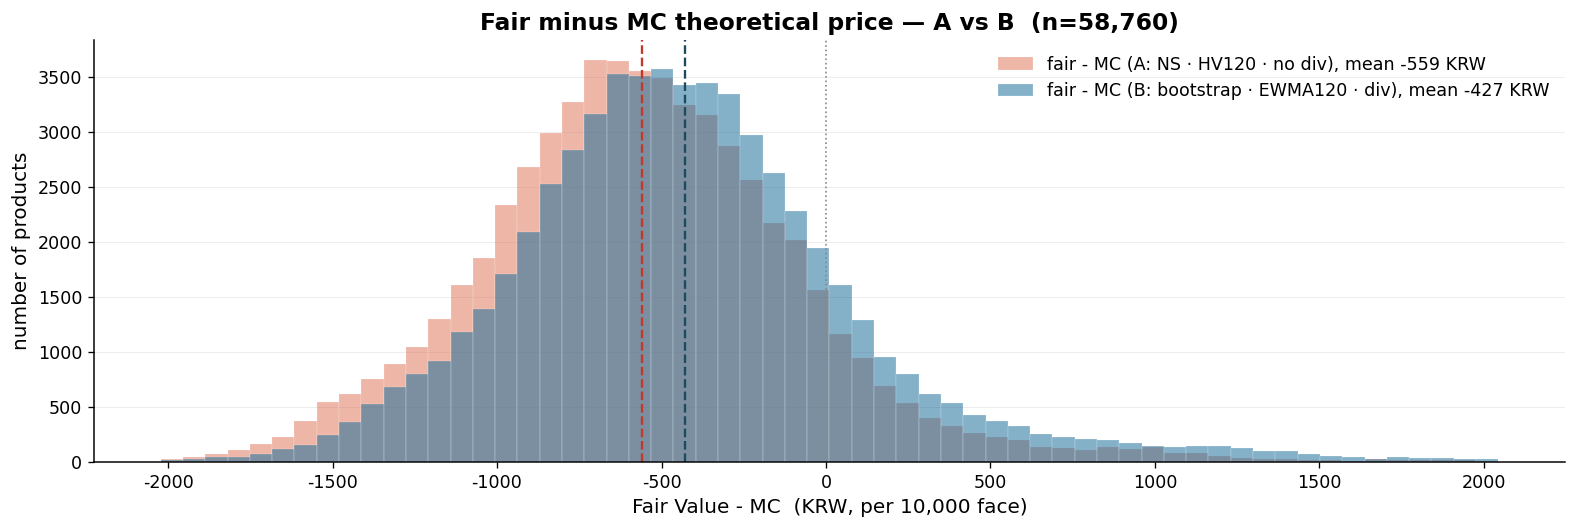

saved -> stage1var_fair_minus_mc_hist.png


In [2]:
fa, fb = (S.fair - V.mc_A) * FACE, (S.fair - V.mc_B) * FACE
m_ = ok.values
T = pd.DataFrame({lab: {"mean": x[m_].mean(), "median": x[m_].median(), "MAE": x[m_].abs().mean(), "sd": x[m_].std(),
                        "MC mean": (S.fair * FACE - x)[m_].mean()}
                  for lab, x in [("A: NS · HV120 · no div", fa), ("B: bootstrap · EWMA120 · div", fb)]}).T
T.to_csv(fm.stat("stage1var_mc_level"))
print(f"사용 상품 {int(m_.sum()):,}개, 원 (액면 10,000 기준)"); print(T.round(0).to_string())
print(f"B − A MC 변화: 평균 {((V.mc_B - V.mc_A) * FACE)[m_].mean():+.0f}원, 표준편차 {((V.mc_B - V.mc_A) * FACE)[m_].std():.0f}원")

fa_, fb_ = fa[m_], fb[m_]
bins = np.linspace(min(fa_.quantile(.001), fb_.quantile(.001)), max(fa_.quantile(.999), fb_.quantile(.999)), 61)
fig, ax = plt.subplots(figsize=(13.333, 4.6))
ax.hist(fa_, bins=bins, color="#e07a5f", alpha=.55, edgecolor="white", lw=.2, label=f"fair - MC (A: NS · HV120 · no div), mean {fa_.mean():,.0f} KRW")
ax.hist(fb_, bins=bins, color="#1f6f9c", alpha=.55, edgecolor="white", lw=.2, label=f"fair - MC (B: bootstrap · EWMA120 · div), mean {fb_.mean():,.0f} KRW")
ax.axvline(fa_.mean(), color="#c0392b", lw=1.4, ls="--"); ax.axvline(fb_.mean(), color="#1c4a5f", lw=1.4, ls="--")
ax.axvline(0, color="#888", lw=1, ls=":")
ax.set_xlabel("Fair Value - MC  (KRW, per 10,000 face)"); ax.set_ylabel("number of products")
ax.set_title(f"Fair minus MC theoretical price — A vs B  (n={int(m_.sum()):,})")
ax.grid(axis="y", color="#dddddd", lw=.5, alpha=.6); ax.legend(loc="upper right")
fig.tight_layout(); fig.savefig(fm.image("stage1var_fair_minus_mc_hist")); plt.show()
print("saved ->", fm.image("stage1var_fair_minus_mc_hist").name)

## 18-2. Stage-1 R² — 3_evaluate 의 Per-stage R² 와 같은 형식

막대 = 5시드 평균. 정본(HV180 · NS · q = 0)의 Stage-1 R² 는 DeepONet 0.94, XGB 0.88 이다 (3_evaluate).

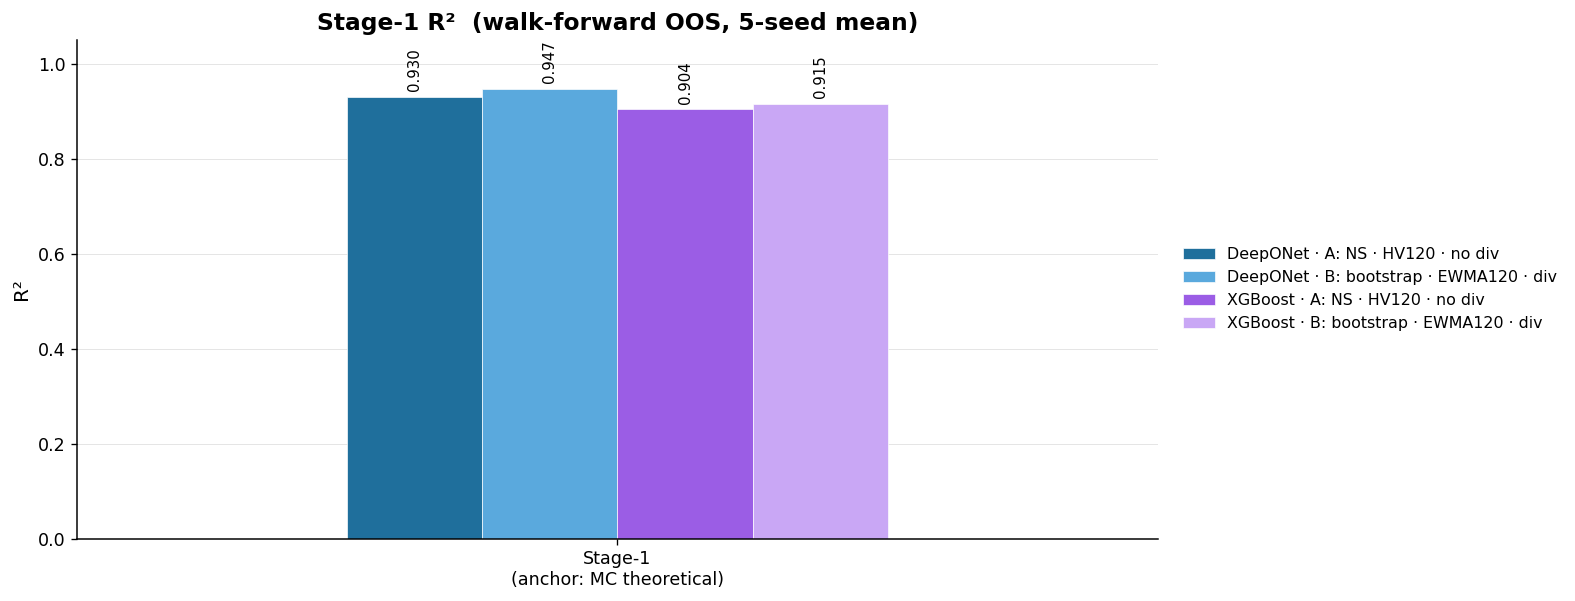

saved -> stage1var_stage_r2.png


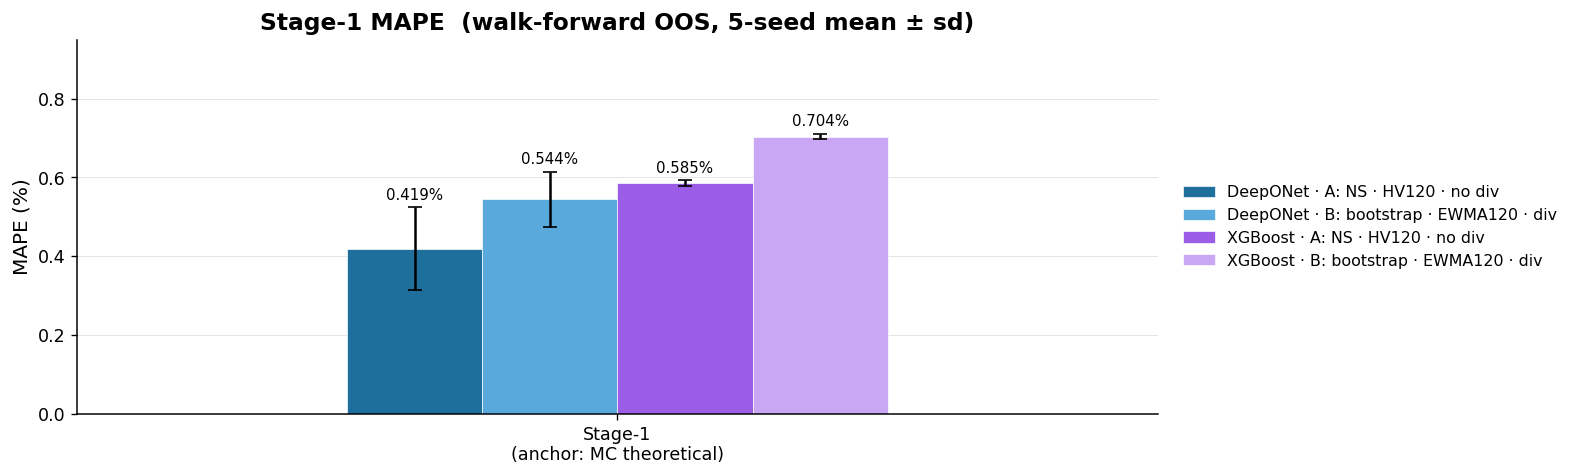

saved -> stage1var_mape.png

=== 5시드 평균 ± 표준편차 (MAE · RMSE 는 원, 액면 10,000 기준) ===
                  R2              MAE               RMSE             MAPE        
                mean     std     mean      std      mean      std    mean     std
model    var                                                                     
deeponet A    0.9305  0.0499  40.8148  10.1520   71.8499  23.4321  0.4192  0.1043
         B    0.9468  0.0094  52.2922   6.8046   82.9887   7.4849  0.5440  0.0707
xgb      A    0.9041  0.0011  57.2285   0.7831   87.8932   0.5191  0.5854  0.0077
         B    0.9155  0.0012  67.7887   0.7002  104.9488   0.7220  0.7037  0.0070

=== 시드별 R² ===
model deeponet             xgb        
var          A       B       A       B
seed                                  
0       0.9512  0.9605  0.9043  0.9137
1       0.8424  0.9346  0.9031  0.9161
2       0.9556  0.9462  0.9040  0.9149
3       0.9403  0.9437  0.9033  0.9166
4       0.9629  0.9490  0.9059  0.9162

=== B − A (같은 시

In [3]:
agg = R.groupby(["model", "var"])[["R2", "MAE", "RMSE", "MAPE"]].agg(["mean", "std"])
agg.to_csv(fm.stat("stage1var_summary"))
fig, ax = plt.subplots(figsize=(_plot.SLIDE_W, _plot.BAND_H))
w = 0.8 / len(SER)
for j, (m, v, lab, col) in enumerate(SER):
    off = (j - (len(SER) - 1) / 2) * w
    val = agg.loc[(m, v), ("R2", "mean")]
    ax.bar(off, val, w, label=lab, color=col, edgecolor="white", linewidth=0.4)
    ax.text(off, val + 0.012, f"{val:.3f}", ha="center", va="bottom", fontsize=9, rotation=90)
ax.set_xticks([0]); ax.set_xticklabels(["Stage-1\n(anchor: MC theoretical)"])
ax.set_xlim(-0.8, 0.8); ax.set_ylim(0, 1.05); ax.set_ylabel("R²")
ax.axhline(0, color="#444", lw=0.6); ax.grid(axis="y", color="#cccccc", lw=0.6, alpha=0.5)
ax.set_title("Stage-1 R²  (walk-forward OOS, 5-seed mean)")
ax.legend(fontsize=9.5, loc="center left", bbox_to_anchor=(1.01, 0.5))
fig.tight_layout(); fig.savefig(fm.image("stage1var_stage_r2")); plt.show()
print("saved ->", fm.image("stage1var_stage_r2").name)
fig, ax = plt.subplots(figsize=(_plot.SLIDE_W, _plot.BAND_H * 0.8))
for j, (m, v, lab, col) in enumerate(SER):
    off = (j - (len(SER) - 1) / 2) * w
    val, err = agg.loc[(m, v), ("MAPE", "mean")], agg.loc[(m, v), ("MAPE", "std")]
    ax.bar(off, val, w, yerr=err, capsize=4, label=lab, color=col, edgecolor="white", linewidth=0.4)
    ax.text(off, val + err + 0.012, f"{val:.3f}%", ha="center", va="bottom", fontsize=9)
ax.set_xticks([0]); ax.set_xticklabels(["Stage-1\n(anchor: MC theoretical)"])
ax.set_xlim(-0.8, 0.8); ax.set_ylim(0, max(agg[("MAPE", "mean")]) * 1.35); ax.set_ylabel("MAPE (%)")
ax.grid(axis="y", color="#cccccc", lw=0.6, alpha=0.5)
ax.set_title("Stage-1 MAPE  (walk-forward OOS, 5-seed mean ± sd)")
ax.legend(fontsize=9.5, loc="center left", bbox_to_anchor=(1.01, 0.5))
fig.tight_layout(); fig.savefig(fm.image("stage1var_mape")); plt.show()
print("saved ->", fm.image("stage1var_mape").name)

print("\n=== 5시드 평균 ± 표준편차 (MAE · RMSE 는 원, 액면 10,000 기준) ===")
print(agg.round(4).to_string())
print("\n=== 시드별 R² ===")
print(R.pivot_table(index="seed", columns=["model", "var"], values="R2").round(4).to_string())
W = R.pivot_table(index=["model", "seed"], columns="var")
D = pd.DataFrame({m: {c: f"{(W.loc[m][(c, 'B')] - W.loc[m][(c, 'A')]).mean():+.4f} ± {(W.loc[m][(c, 'B')] - W.loc[m][(c, 'A')]).std():.4f}"
                      for c in ["R2", "MAE", "RMSE", "MAPE"]} for m in MODELS})
D.to_csv(fm.stat("stage1var_paired_diff"))
print("\n=== B − A (같은 시드 짝, 평균 ± sd) ==="); print(D.to_string())

## 18-3. 폴드(시기)별 Stage-1 성능

walk-forward test 4구간(뒤 40% 를 10% 씩)마다 Stage-1 R² · MAE · MAPE 를 본다 (5시드 평균).

                                       R2      MAE      RMSE    MAPE
model    var fold period                                            
deeponet A   0    2021-04~2022-03  0.9758  21.8866   30.2700  0.2217
             1    2022-03~2023-04  0.8593  76.5239  107.5557  0.7913
             2    2023-04~2024-08  0.9583  22.5006   34.4904  0.2270
             3    2024-08~2026-05  0.9354  42.3560   76.8866  0.4369
         B   0    2021-04~2022-03  0.9675  33.8525   44.0030  0.3457
             1    2022-03~2023-04  0.8969  95.9200  125.1010  1.0051
             2    2023-04~2024-08  0.9488  31.0611   43.9836  0.3146
             3    2024-08~2026-05  0.9502  48.3149   88.2569  0.5103
xgb      A   0    2021-04~2022-03  0.9429  35.3819   46.4834  0.3565
             1    2022-03~2023-04  0.8978  69.0347  101.9279  0.7191
             2    2023-04~2024-08  0.8019  57.3839   75.4435  0.5749
             3    2024-08~2026-05  0.8631  67.1640  112.5659  0.6915
         B   0    2021-04~2022-03 

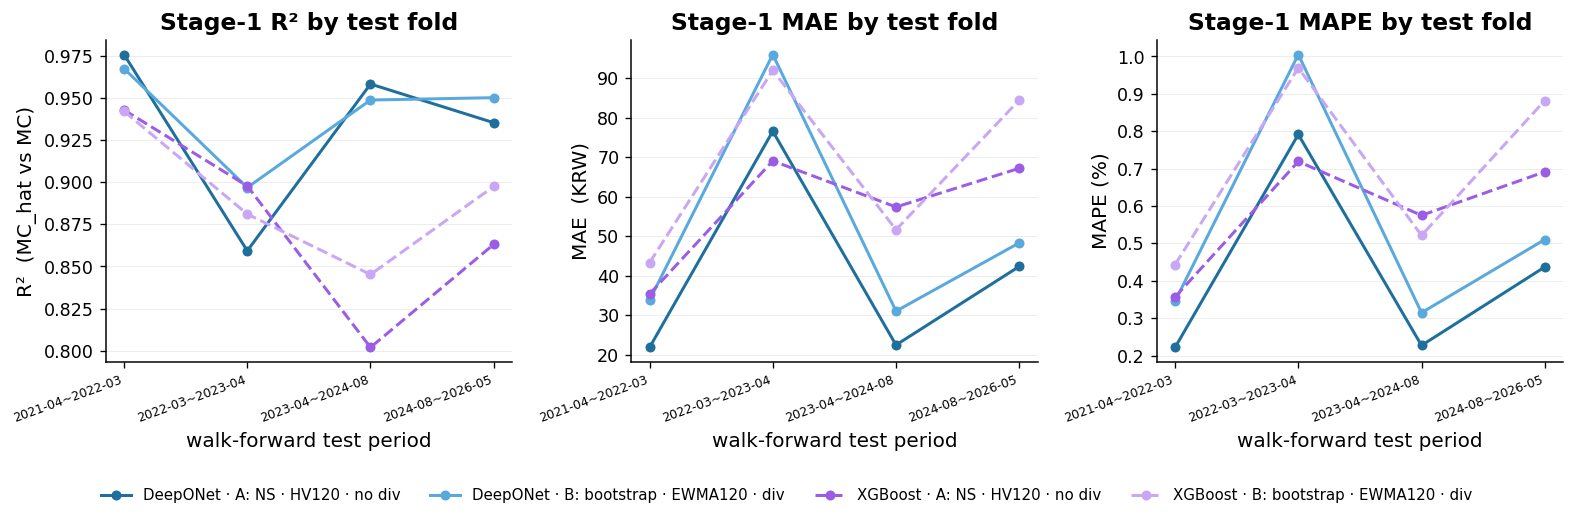

saved -> stage1var_by_fold.png


In [4]:
rows = []
for (m, v, s), p in P.items():
    for k, q in p.groupby("fold"):
        rows.append({"model": m, "var": v, "seed": s, "fold": k,
                     "period": f"{pd.Timestamp.fromordinal(int(q.isu_ord.min())):%Y-%m}~{pd.Timestamp.fromordinal(int(q.isu_ord.max())):%Y-%m}",
                     **sc(q)})
FD = pd.DataFrame(rows)
FT = FD.groupby(["model", "var", "fold", "period"])[["R2", "MAE", "RMSE", "MAPE"]].mean()
FT.to_csv(fm.stat("stage1var_by_fold")); print(FT.round(4).to_string())

per = FD.drop_duplicates("fold").sort_values("fold").period.tolist()
fig, ax = plt.subplots(1, 3, figsize=(13.333, 4.4))
for m, v, lab, col in SER:
    q = FD[(FD["model"] == m) & (FD["var"] == v)].groupby("fold")[["R2", "MAE", "MAPE"]].mean()
    ls = "-" if m == "deeponet" else "--"
    ax[0].plot(q.index, q.R2, ls, marker="o", ms=5, lw=1.8, color=col, label=lab)
    ax[1].plot(q.index, q.MAE, ls, marker="o", ms=5, lw=1.8, color=col, label=lab)
    ax[2].plot(q.index, q.MAPE, ls, marker="o", ms=5, lw=1.8, color=col, label=lab)
for a, yl, tt in [(ax[0], "R²  (MC_hat vs MC)", "Stage-1 R² by test fold"), (ax[1], "MAE  (KRW)", "Stage-1 MAE by test fold"), (ax[2], "MAPE (%)", "Stage-1 MAPE by test fold")]:
    a.set_xticks(range(len(per))); a.set_xticklabels(per, fontsize=7.5, rotation=20, ha="right"); a.set_xlabel("walk-forward test period")
    a.set_ylabel(yl); a.set_title(tt); a.grid(axis="y", color="#dddddd", lw=.5, alpha=.6)
h, l = ax[0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=4, fontsize=9, frameon=False, bbox_to_anchor=(.5, 0))
fig.tight_layout(rect=(0, .08, 1, 1)); fig.savefig(fm.image("stage1var_by_fold")); plt.show()
print("saved ->", fm.image("stage1var_by_fold").name)

## 18-4. 오차 분포 — MC_hat − MC, 그리고 B 에서 왜 넓어지나

5시드 예측을 모두 모은 분포다. B 의 분포가 눈에 띄게 넓다. 원인을 세 가지로 나눠 본다.

1. **타깃이 넓어졌다** — B 의 MC 는 배당 · EWMA 로 상품별 차이가 커진다. 오른쪽 패널처럼 오차를 각 변형의 **타깃 표준편차로 나누면** 두 분포가 겹친다.
2. **상대 정확도는 그대로다** — MAE ÷ 타깃 sd 가 거의 같고, 오차 sd ÷ 타깃 sd 는 오히려 B 가 작다 (그래서 R² 는 B 가 높다).
3. **MC 난수 오차는 하한일 뿐 주원인이 아니다** — 같은 상품을 다른 난수로 다시 프라이싱해 잰 MC 1회 표준오차는 A · B 모두 10원 미만이다
   (`scratch/mc_noise_check.py`). 배당락 시점처럼 stage-1 입력에 없는 정보(연 배당수익률만 입력)도 오차에 남지만,
   노트북 16 에서 잰 시점 효과 자체가 상품당 7.5원 수준이다.

원 단위 (액면 10,000) · MC 난수 표준오차는 400개 상품 재프라이싱으로 측정
              타깃 sd     MAE    오차 sd  MAE/타깃sd  오차sd/타깃sd  MC 난수 표준오차
deeponet A  283.873  40.815   74.756     0.144      0.263       6.989
deeponet B  361.035  52.292   81.429     0.145      0.226       8.573
xgb A       283.873  57.228   87.768     0.202      0.309       6.989
xgb B       361.035  67.789  101.508     0.188      0.281       8.573


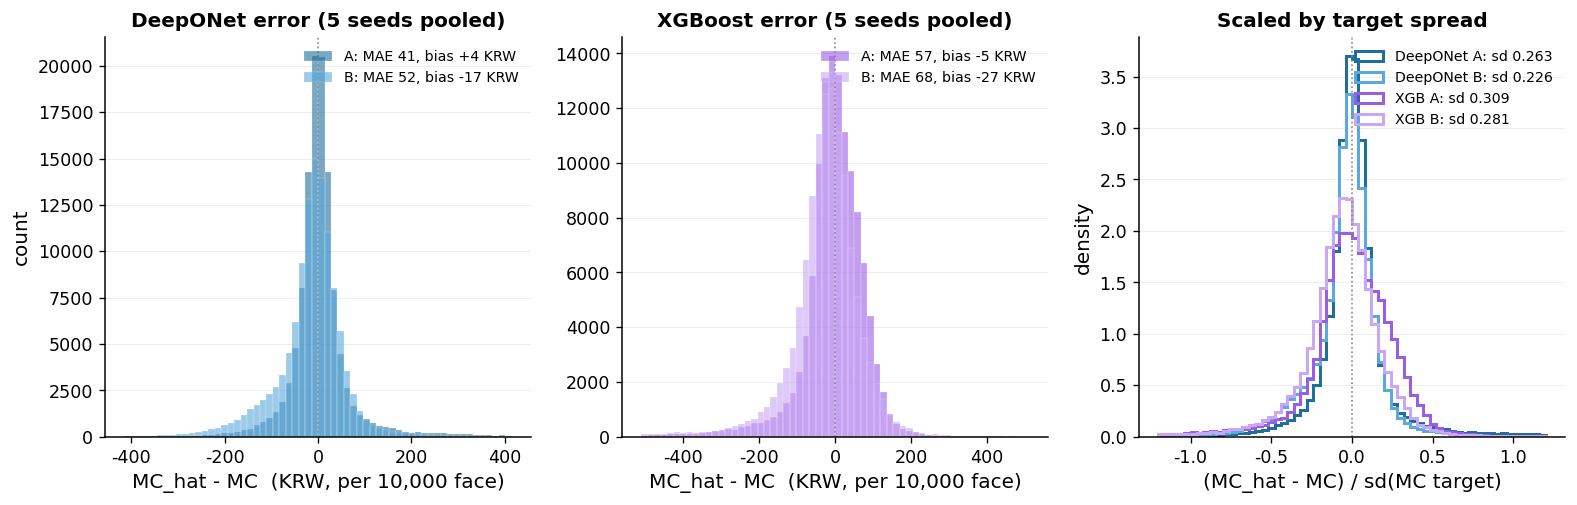

saved -> stage1var_error_hist.png


In [5]:
ERR = {(m, v): pd.concat([(P[(m, v, s)].mc_pred - P[(m, v, s)].mc_true) * FACE for s in SEEDS]) for m in MODELS for v in "AB"}
TSD = {v: P[("xgb", v, 0)].mc_true.std() * FACE for v in "AB"}          # 각 변형의 OOS 타깃(MC) 표준편차
NOISE = pd.read_csv(fm.stat("stage1var_mc_noise"), encoding="utf-8-sig").set_index("var")
T = pd.DataFrame({f"{m} {v}": {"타깃 sd": TSD[v], "MAE": ERR[(m, v)].abs().mean(), "오차 sd": ERR[(m, v)].std(),
                               "MAE/타깃sd": ERR[(m, v)].abs().mean() / TSD[v], "오차sd/타깃sd": ERR[(m, v)].std() / TSD[v],
                               "MC 난수 표준오차": NOISE.loc[v, "mc_stderr_KRW"]}
                  for m in MODELS for v in "AB"}).T
T.to_csv(fm.stat("stage1var_error_scale"))
print("원 단위 (액면 10,000) · MC 난수 표준오차는 400개 상품 재프라이싱으로 측정"); print(T.round(3).to_string())

fig, ax = plt.subplots(1, 3, figsize=(13.333, 4.4))
for a, m, ttl in [(ax[0], "deeponet", "DeepONet"), (ax[1], "xgb", "XGBoost")]:
    lim = max(ERR[(m, "A")].abs().quantile(.995), ERR[(m, "B")].abs().quantile(.995)); bins = np.linspace(-lim, lim, 61)
    for (mm, v, lab, col) in [x for x in SER if x[0] == m]:
        a.hist(ERR[(m, v)], bins=bins, color=col, alpha=.6, edgecolor="white", lw=.2,
               label=f"{v}: MAE {ERR[(m, v)].abs().mean():.0f}, bias {ERR[(m, v)].mean():+.0f} KRW")
    a.axvline(0, color="#888", lw=1, ls=":")
    a.set_xlabel("MC_hat - MC  (KRW, per 10,000 face)"); a.set_title(f"{ttl} error (5 seeds pooled)", fontsize=12)
    a.grid(axis="y", color="#dddddd", lw=.5, alpha=.6); a.legend(fontsize=8.5)
ax[0].set_ylabel("count")
bins = np.linspace(-1.2, 1.2, 61)
for (m, v, lab, col) in SER:
    ax[2].hist(ERR[(m, v)] / TSD[v], bins=bins, histtype="step", lw=1.8, color=col, density=True,
               label=f"{'DeepONet' if m == 'deeponet' else 'XGB'} {v}: sd {(ERR[(m, v)] / TSD[v]).std():.3f}")
ax[2].axvline(0, color="#888", lw=1, ls=":")
ax[2].set_xlabel("(MC_hat - MC) / sd(MC target)"); ax[2].set_ylabel("density")
ax[2].set_title("Scaled by target spread", fontsize=12); ax[2].legend(fontsize=8.5)
ax[2].grid(axis="y", color="#dddddd", lw=.5, alpha=.6)
fig.tight_layout(); fig.savefig(fm.image("stage1var_error_hist")); plt.show()
print("saved ->", fm.image("stage1var_error_hist").name)

## 결론 — B 는 R² 가 조금 높고 원 단위 오차는 조금 크다

OOS test 23,486개, 5시드 평균 ± 표준편차. B − A 는 같은 시드끼리의 차이다.

| Stage-1 (MC_hat vs MC) | DeepONet A | DeepONet B | XGBoost A | XGBoost B |
|---|---|---|---|---|
| R² | 0.9305 ± 0.0499 | 0.9468 ± 0.0094 | 0.9041 ± 0.0011 | 0.9155 ± 0.0012 |
| MAE (원) | 40.8 ± 10.2 | 52.3 ± 6.8 | 57.2 ± 0.8 | 67.8 ± 0.7 |
| RMSE (원) | 71.8 ± 23.4 | 83.0 ± 7.5 | 87.9 ± 0.5 | 104.9 ± 0.7 |
| MAPE (%) | 0.419 ± 0.104 | 0.544 ± 0.071 | 0.585 ± 0.008 | 0.704 ± 0.007 |

| B − A (시드 짝) | DeepONet | XGBoost |
|---|---|---|
| R² | +0.0163 ± 0.0434 (B 가 높은 시드 3/5) | +0.0114 ± 0.0017 (B 가 높은 시드 5/5) |
| MAE (원) | +11.5 ± 7.6 | +10.6 ± 1.0 |
| RMSE (원) | +11.1 ± 18.9 | +17.1 ± 0.9 |

0. **MC 분포**: 공정가 − MC 평균이 A -559원 → B -427원, MAE 635 → 567원으로 B 의 MC 가 공정가 쪽으로 옮겨가고(평균 +132원), 분포는 넓어진다 (표준편차 495 → 531원).
1. **Stage-1 R² 는 두 변형 모두 정본 수준이다** (정본 DeepONet 0.94 · XGB 0.88). XGB 는 A · B 모두 정본보다 높다.
   DeepONet A 의 평균이 낮은 것은 시드 하나(0.842) 때문이고, 나머지 4시드는 0.940 ~ 0.963 다.
2. **R² 는 B 가 조금 높다** — DeepONet +0.0163 ± 0.0434, XGBoost +0.0114 ± 0.0017 (XGBoost 는 5시드 모두 B 가 높음).
3. **원 단위 오차는 B 가 조금 크다 — 타깃이 넓어진 만큼이다** (18-4). MAE 는 DeepONet +11.5 ± 7.6원,
   XGBoost +10.6 ± 1.0원 늘지만, 타깃 표준편차가 A 284원 → B 361원(1.27배)으로 넓어진 결과다.
   **MAE ÷ 타깃 sd 는 거의 그대로이고**(DeepONet 0.144 → 0.145, XGBoost 0.202 → 0.188),
   오차 sd ÷ 타깃 sd 는 오히려 줄어든다(0.263 → 0.226, 0.309 → 0.281) — 그래서 R² 가 올라간다.
   타깃이 넓어진 이유는 B 의 MC 가 상품마다 다르게 움직이기 때문이다(200개 표본 기준 배당 sd 94원 · EWMA sd 114원 · 커브 sd 23원).
   MC 난수 자체의 표준오차는 A 7.0원 · B 8.6원으로 오차의 하한일 뿐 주원인이 아니다.
4. **정리**: stage-1 이 MC 를 배우는 능력은 두 변형에서 거의 같다. B 의 입력(배당수익률 · 부트스트랩 커브 · EWMA 변동성)이
   B 의 MC 를 A 와 비슷한 정확도로 설명하므로, stage-1 을 B 로 바꿔도 대리모형 성능은 유지된다.

**한계**: stage-2 는 돌리지 않았다. 한 번의 MC(40,000 경로) 값을 참값으로 쓴다. 가격 캐시가 2025-06-30 에 끊긴 34종목 때문에
30개 상품을 뺐다 (정본 MC 도 같은 캐시를 써서 이 상품들의 σ · 상관은 오래된 가격 기준이다 — 캐시 갱신 필요).